In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("retail_sales_dataset (2).csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe())

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Descriptive Statistics:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Sales by Age Group:
Age Group
Under 18     11215
18-25        73335
26-35        98480
36-45        91870
46-55       100690
56-65        80410
65+              0
Name: Total Amount, dtype: int64


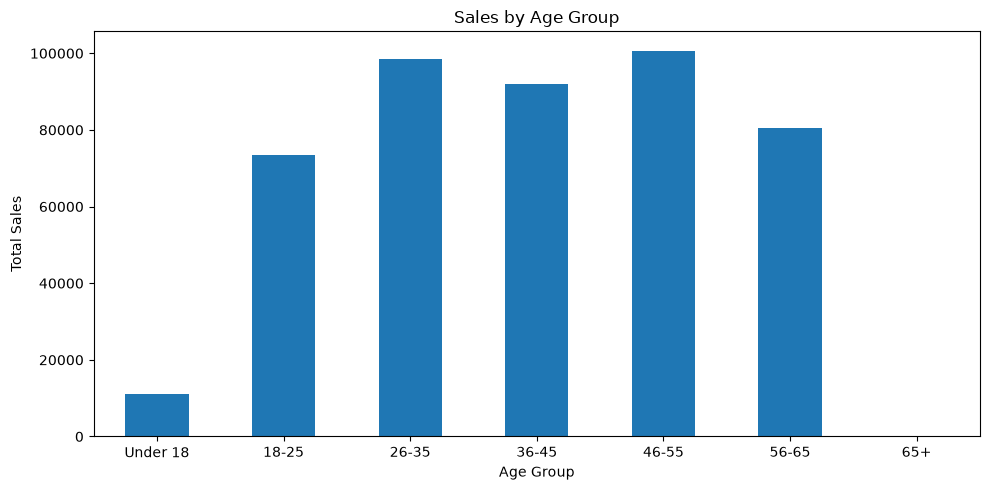

In [5]:
# Create age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_sales = df.groupby('Age Group', observed=False)['Total Amount'].sum()

print("Sales by Age Group:")
print(age_sales)

# Visualization
plt.figure(figsize=(10, 5))
age_sales.plot(kind='bar')
plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Gender-wise Sales:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


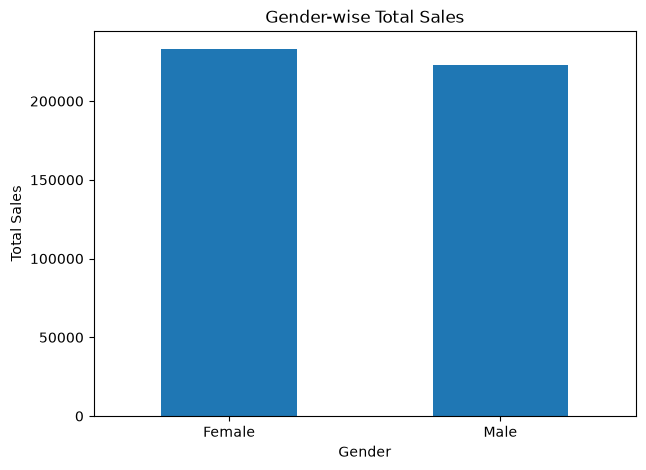

In [6]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print("Gender-wise Sales:")
print(gender_sales)

plt.figure(figsize=(7,5))
gender_sales.plot(kind='bar')

plt.title('Gender-wise Total Sales')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

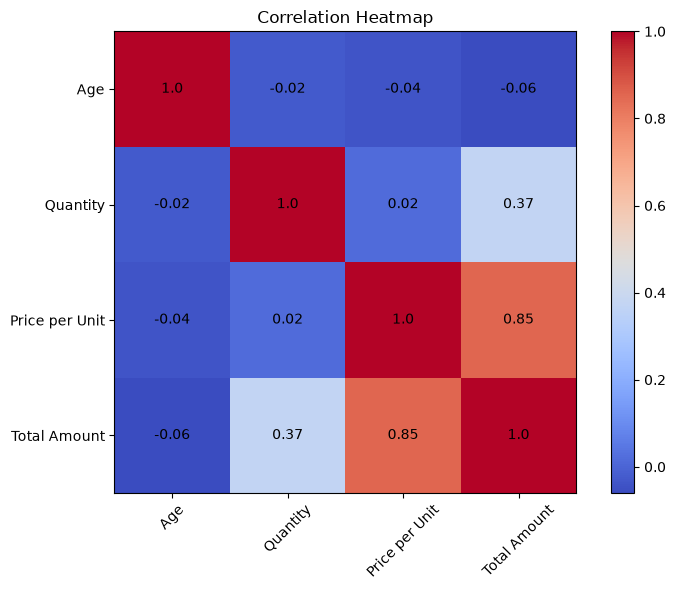

In [7]:
# Correlation Heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

correlation = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

# Correlation values show karna
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, round(correlation.iloc[i, j], 2),
                 ha='center', va='center')

plt.tight_layout()
plt.show()

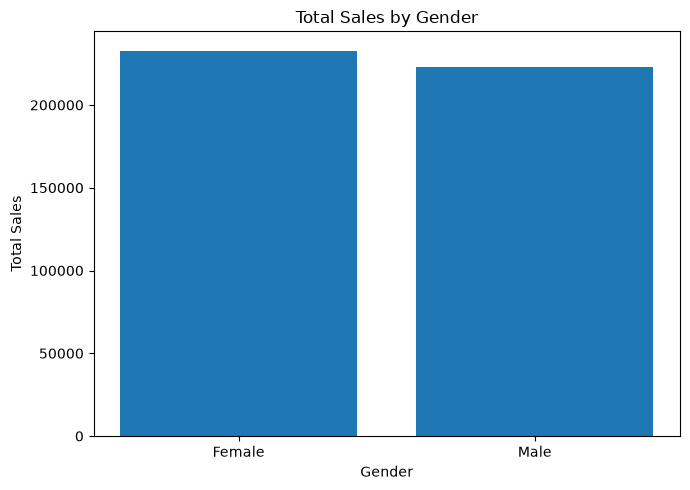

In [8]:
# Additional Visualization: Sales by Gender

gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(7, 5))
plt.bar(gender_sales.index, gender_sales.values)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [9]:
# Final Business Insights

print("FINAL BUSINESS INSIGHTS")
print("-" * 50)

print("1. Electronics generated the highest category-wise sales.")
print("2. The 26-35 age group generated the highest sales among the analyzed age groups.")
print("3. Female customers generated slightly higher total sales than male customers.")
print("4. Price per Unit has a strong positive relationship with Total Amount.")
print("5. Quantity has a moderate positive relationship with Total Amount.")

print("\nBUSINESS RECOMMENDATIONS")
print("-" * 50)

print("1. Focus inventory and promotions on high-performing product categories.")
print("2. Create targeted offers for the highest-sales age group.")
print("3. Monitor pricing and quantity combinations to improve revenue.")

print("\nCONCLUSION")
print("-" * 50)

print("The retail sales analysis provides insights into sales trends,")
print("customer demographics, product categories and revenue relationships.")
print("These findings can support better inventory planning,")
print("customer targeting and sales strategy.")

FINAL BUSINESS INSIGHTS
--------------------------------------------------
1. Electronics generated the highest category-wise sales.
2. The 26-35 age group generated the highest sales among the analyzed age groups.
3. Female customers generated slightly higher total sales than male customers.
4. Price per Unit has a strong positive relationship with Total Amount.
5. Quantity has a moderate positive relationship with Total Amount.

BUSINESS RECOMMENDATIONS
--------------------------------------------------
1. Focus inventory and promotions on high-performing product categories.
2. Create targeted offers for the highest-sales age group.
3. Monitor pricing and quantity combinations to improve revenue.

CONCLUSION
--------------------------------------------------
The retail sales analysis provides insights into sales trends,
customer demographics, product categories and revenue relationships.
These findings can support better inventory planning,
customer targeting and sales strategy.
